# Đo Vận Tốc Dòng Xe Qua Optical Flow (TV4)
**Thành viên thực hiện:** Phạm Võ Văn Quyến  
**Mục đích:** Minh hoạ cách sử dụng lớp `MotionEstimator` được định nghĩa trực tiếp trong sổ ghi chép này để ước lượng vận tốc dòng xe từ một tệp video giao thông được tải lên từ máy tính cá nhân.

In [23]:
import cv2
import numpy as np
from IPython.display import clear_output, Image, display # Bao gồm các import cần thiết cho chức năng hiển thị

class MotionEstimator:
    """
    Ước lượng vận tốc dòng xe qua Optical Flow (Chương 3)
    """
    def __init__(self, noise_threshold=1.0):
        self.prev_gray = None
        self.noise_threshold = noise_threshold

    def estimate_speed(self, current_frame):
        if len(current_frame.shape) == 3:
            gray = cv2.cvtColor(current_frame, cv2.COLOR_BGR2GRAY)
        else:
            gray = current_frame

        if self.prev_gray is None:
            self.prev_gray = gray
            return 0.0, np.zeros_like(gray, dtype=np.float32)

        flow = cv2.calcOpticalFlowFarneback(
            self.prev_gray, gray, None,
            pyr_scale=0.5, levels=3, winsize=15,
            iterations=3, poly_n=5, poly_sigma=1.2, flags=0
        )
        self.prev_gray = gray

        magnitude, _ = cv2.cartToPolar(flow[..., 0], flow[..., 1])

        # Lọc bỏ nhiễu rung lắc nhỏ
        valid_magnitudes = magnitude[magnitude >= self.noise_threshold]

        # Tính vận tốc trung bình của toàn bộ dòng xe đang lưu thông trên làn đường
        if len(valid_magnitudes) > 0:
            avg_speed = float(np.mean(valid_magnitudes))
        else:
            avg_speed = 0.0

        return avg_speed, magnitude

## Tải Video từ Máy Tính Cá Nhân

Chúng ta sẽ sử dụng `google.colab.files.upload()` để tải một tệp video từ máy tính của bạn. Sau khi tải lên, đường dẫn của nó sẽ được sử dụng để xử lý.

In [ ]:
from google.colab import files
import os

print("Vui lòng tải tệp video của bạn lên:")
uploaded = files.upload()

if uploaded:
    # Giả sử chỉ có một tệp được tải lên
    video_filename = list(uploaded.keys())[0]
    video_path = os.path.join(os.getcwd(), video_filename)
    print(f"Video '{video_filename}' đã tải lên thành công!")
    print(f"Đường dẫn video: {video_path}")
else:
    video_path = None
    print("Không có tệp nào được tải lên.")

Vui lòng tải tệp video của bạn lên:


Demo finished.
Last processed frame:


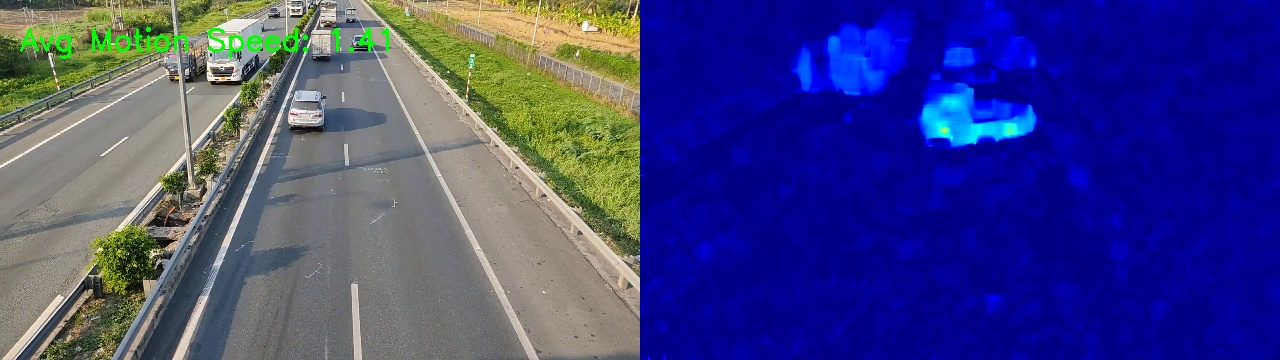

In [22]:
if video_path is None:
    print("Không có tệp video nào được chỉ định. Vui lòng tải video lên ở ô trước.")
else:
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print(f"Lỗi: Không thể mở tệp video tại {video_path}")
    else:
        last_encoded_image = None # Biến để lưu trữ khung hình cuối cùng để hiển thị
        try:
            # Giới hạn khoảng 100 khung hình để demo trong sổ ghi chép tránh bị treo
            for i in range(100):
                ret, frame = cap.read()
                if not ret:
                    print("Không thể đọc khung hình hoặc đã hết video.")
                    break

                # Thay đổi kích thước ảnh để tính toán nhanh hơn
                frame = cv2.resize(frame, (640, 360))

                # Ước tính vận tốc chuyển động
                speed, mag = estimator.estimate_speed(frame)

                # Vẽ tốc độ chuyển động trung bình lên khung hình gốc
                cv2.putText(frame, f"Tốc độ chuyển động trung bình: {speed:.2f}", (20, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

                # Cắt giá trị độ lớn tối đa ở 5.0 để hình dung các chuyển động nhỏ hơn (ví dụ: ô tô ở xa)
                mag_clipped = np.clip(mag, 0, 5.0)
                mag_norm = np.uint8(mag_clipped * (255.0 / 5.0))
                mag_bgr = cv2.applyColorMap(mag_norm, cv2.COLORMAP_JET)

                # Ghép hai hình ảnh cạnh nhau để hiển thị
                combined = np.hstack((frame, mag_bgr))

                # Chuyển đổi để hiển thị trong sổ ghi chép
                _, encoded_image = cv2.imencode('.jpg', combined)
                last_encoded_image = encoded_image # Lưu trữ hình ảnh được mã hóa cuối cùng

                display(Image(data=encoded_image.tobytes()))

                # Xóa đầu ra hiện tại để hiển thị khung hình tiếp theo (tạo hiệu ứng phát video)
                clear_output(wait=True)

        except KeyboardInterrupt:
            print("Phát video đã dừng.")
        finally:
            cap.release()
            print("Demo đã kết thúc.")
            # Hiển thị khung hình cuối cùng đã xử lý một cách tĩnh sau khi vòng lặp kết thúc
            if last_encoded_image is not None:
                print("Khung hình đã xử lý cuối cùng:")
                display(Image(data=last_encoded_image.tobytes()))